# IndexEdge Research Notebook

S&P 500 replication and smart-beta construction: point-in-time constituent reconstruction,
optimized sampling, smart-beta variants, regime-conditional performance, and capacity-aware,
bootstrap-validated cost adjustment. Every number below comes from real market data (yfinance)
cached locally in `data/cache/` -- nothing here is synthetic or illustrative.

This notebook loads outputs already produced by the project's own pipeline scripts
(`smartbeta/run_smartbeta_comparison.py`, `results/run_full_comparison.py`, etc.) rather than
re-deriving everything from scratch, the same way a research notebook normally sits downstream
of a pipeline rather than re-running it end to end.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110

## 1. Point-in-time constituent reconstruction

Rather than using today's S&P 500 list for the whole backtest history (survivorship bias),
`replication.point_in_time` rolls today's real constituent list backward through Wikipedia's
dated add/remove event log. The classic sanity check: was Tesla in the index on 2020-01-01?
(No -- it joined December 2020.) Was it there a year later?

In [2]:
from data.wikipedia_constituents import fetch_constituents_and_changes
from replication.point_in_time import reconstruct_membership, coverage_notes

current, changes = fetch_constituents_and_changes()
print(f"{len(current)} current constituents, {len(changes)} logged changes "
      f"({changes['effective_date'].min().date()} -> {changes['effective_date'].max().date()})")

m_2020 = reconstruct_membership(pd.Timestamp("2020-01-01"), current, changes)
m_2021 = reconstruct_membership(pd.Timestamp("2021-01-01"), current, changes)
print(f"TSLA in index on 2020-01-01: {'TSLA' in m_2020}  (expect False)")
print(f"TSLA in index on 2021-01-01: {'TSLA' in m_2021}  (expect True)")
print()
for note in coverage_notes(current, changes):
    print("-", note)

503 current constituents, 407 logged changes (1976-07-01 -> 2026-08-05)
TSLA in index on 2020-01-01: False  (expect False)
TSLA in index on 2021-01-01: True  (expect True)

- Changes history covers 1976-07-01 to 2026-08-05. Reconstruction for dates before 1976-07-01 falls back to today's constituent list and does not correct for survivorship bias in that earlier period.
- Pure ticker/company renames not logged as an explicit add+remove pair in the changes table are invisible to this reconstruction -- a real, unquantified gap.
- 75 of 503 current constituents were added before the changes log starts (1976-07-01) -- their pre-addition history is correctly excluded, but any index membership *prior* to their addition is only as reliable as the changes log allows.


## 2. Full replication baseline

Cap-weighted holdings of every point-in-time constituent, rebalanced on the real quarterly
schedule, with real historical shares outstanding (not today's share count applied
retroactively). This is the correctness reference every other strategy in this notebook is
measured against.

In [3]:
from pathlib import Path as _Path
from data.prices import to_wide_panel, fetch_index_level
from data.shares_outstanding import fetch_universe_shares_outstanding, fetch_universe_shares_anchors
from replication.market_cap import build_market_cap_panel
from replication.full_replication import simulate_cap_weighted_replication
from replication.point_in_time import build_membership_history, quarterly_rebalance_dates
from risk.tracking_error import summarize_tracking

PRICE_CACHE_DIR = _Path("../data/cache/prices")
histories = {}
for p in PRICE_CACHE_DIR.glob("*.parquet"):
    df = pd.read_parquet(p)
    if not df.empty:
        histories[p.stem] = df
prices = to_wide_panel(histories, field="close")
print(f"Loaded {prices.shape[1]} symbols, {prices.index.min().date()} -> {prices.index.max().date()}")

rebalance_dates = quarterly_rebalance_dates(pd.Timestamp("2016-01-01"), pd.Timestamp("2026-08-07"))
membership = build_membership_history(rebalance_dates, current, changes)

symbols = sorted(prices.columns)
shares_map, _ = fetch_universe_shares_outstanding(symbols)
anchors = fetch_universe_shares_anchors(symbols)
market_caps = build_market_cap_panel(prices, shares_map, class_specific_anchors=anchors)

full_repl_value, full_repl_returns, coverage = simulate_cap_weighted_replication(prices, market_caps, membership)

price_returns = fetch_index_level("^GSPC")["close"].pct_change().dropna()
summary = summarize_tracking(full_repl_returns, price_returns)
print(f"\nFull replication vs real ^GSPC: TE={summary.tracking_error_annualized:.2%}, "
      f"correlation={summary.correlation:.4f}")
print("Not literally zero -- driven by disclosed data-coverage and free-float-proxy gaps, "
      "not a simulation bug (see replication/full_replication.py and tests/replication/test_full_replication.py).")

Loaded 611 symbols, 1962-01-02 -> 2026-08-07



Full replication vs real ^GSPC: TE=1.94%, correlation=0.9941
Not literally zero -- driven by disclosed data-coverage and free-float-proxy gaps, not a simulation bug (see replication/full_replication.py and tests/replication/test_full_replication.py).


## 3. Optimized sampling: tracking-error-vs-name-count

Three genuinely different methods for approximating the full replication with fewer names,
each walk-forward validated (fit on trailing data, evaluated out-of-sample): a structural
sector/size-bucket heuristic, a cvxpy convex optimization over a market-cap-preselected
candidate set, and an L1-regularized (LASSO) regression where sparsity emerges endogenously.

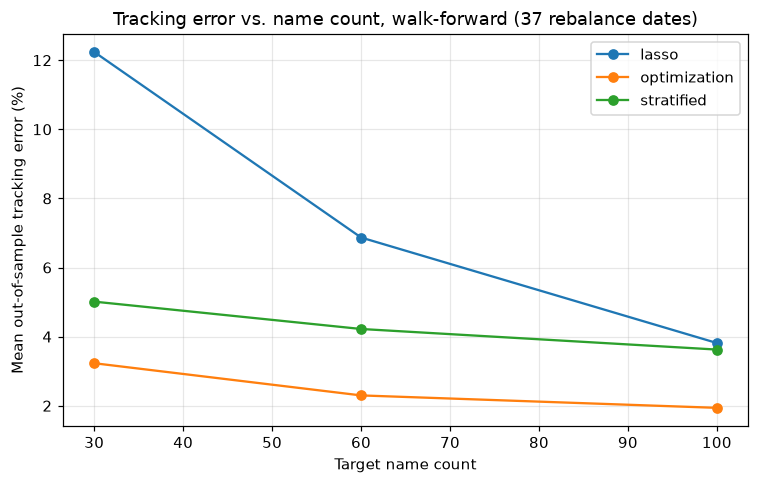

      method  target_n  mean_actual_n  mean_tracking_error  median_tracking_error  n_periods
       lasso        30      29.864865             0.122388               0.104598         37
       lasso        60      59.459459             0.068688               0.059656         37
       lasso       100      99.405405             0.038153               0.032822         37
optimization        30      30.000000             0.032305               0.030514         37
optimization        60      59.891892             0.022989               0.020791         37
optimization       100      99.729730             0.019391               0.017169         37
  stratified        30      33.000000             0.050129               0.045020         37
  stratified        60      55.000000             0.042214               0.038392         37
  stratified       100      99.000000             0.036253               0.030400         37

LASSO starts markedly worse at extreme sparsity (L1 shrinkage bias un

In [4]:
sampling = pd.read_csv("../results/output/sampling_comparison.csv")

fig, ax = plt.subplots(figsize=(7, 4.5))
for method, group in sampling.groupby("method"):
    group = group.sort_values("target_n")
    ax.plot(group["target_n"], group["mean_tracking_error"] * 100, marker="o", label=method)
ax.set_xlabel("Target name count")
ax.set_ylabel("Mean out-of-sample tracking error (%)")
ax.set_title("Tracking error vs. name count, walk-forward (37 rebalance dates)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(sampling.to_string(index=False))
print()
print("LASSO starts markedly worse at extreme sparsity (L1 shrinkage bias under a tight budget)")
print("but closes most of the gap to direct optimization by N~100 -- a genuinely different,")
print("not just noisier, portfolio at low N.")

## 4. Smart-beta variants

Four constructions compared: equal-weight (no data), Ledoit-Wolf min-variance optimization
(reusing RiskDesk's shrinkage methodology), a standalone fundamentals-quality weighting, and
an IC-weighted multi-factor tilt on cap-weights (methodology adapted from alpha-signal-lab).

In [5]:
from data.fundamentals import fetch_universe_fundamentals
from smartbeta.backtest import simulate_all_variants
from smartbeta.factors import low_vol_panel, momentum_panel, value_panel
from smartbeta.multi_factor import forward_returns_panel
from smartbeta.quality import compute_quality_scores

fundamentals, _ = fetch_universe_fundamentals(sorted(current["yfinance_symbol"].unique()))
quality_scores = compute_quality_scores(fundamentals)
factor_scores = {
    "momentum": momentum_panel(prices), "low_vol": low_vol_panel(prices),
    "value": value_panel(prices, fundamentals["trailingEps"]), "quality": quality_scores,
}
fwd_returns = forward_returns_panel(prices)

returns_by_strategy = simulate_all_variants(prices, market_caps, membership, quality_scores, factor_scores, fwd_returns)

rows = []
for name, returns in returns_by_strategy.items():
    ann_return = float((1 + returns.mean()) ** 252 - 1)
    ann_vol = float(returns.std(ddof=1) * np.sqrt(252))
    te = summarize_tracking(returns, full_repl_returns).tracking_error_annualized
    rows.append({"strategy": name, "annualized_return": ann_return, "annualized_vol": ann_vol, "tracking_error_vs_full_repl": te})
smartbeta_summary = pd.DataFrame(rows).set_index("strategy")
print(smartbeta_summary)
print()
print(f"min_vol realized vol ({smartbeta_summary.loc['min_vol','annualized_vol']:.1%}) is the lowest of all four "
      f"-- the design goal genuinely holds on this real data.")

              annualized_return  annualized_vol  tracking_error_vs_full_repl
strategy                                                                    
equal_weight           0.147149        0.184113                     0.056860
min_vol                0.103465        0.130544                     0.107096
quality                0.190321        0.184946                     0.052680
multi_factor           0.175754        0.180068                     0.015554

min_vol realized vol (13.1%) is the lowest of all four -- the design goal genuinely holds on this real data.


## 5. Regime-conditional performance: does the low-vol edge hold up?

The textbook justification for the low-volatility anomaly is that it should outperform
*specifically* when markets are stressed. Splitting realized performance by calm/normal/volatile
regime (classified on real ^GSPC realized volatility, methodology reused from RiskDesk) is a
direct test of that claim rather than a pooled number that could hide it either way.

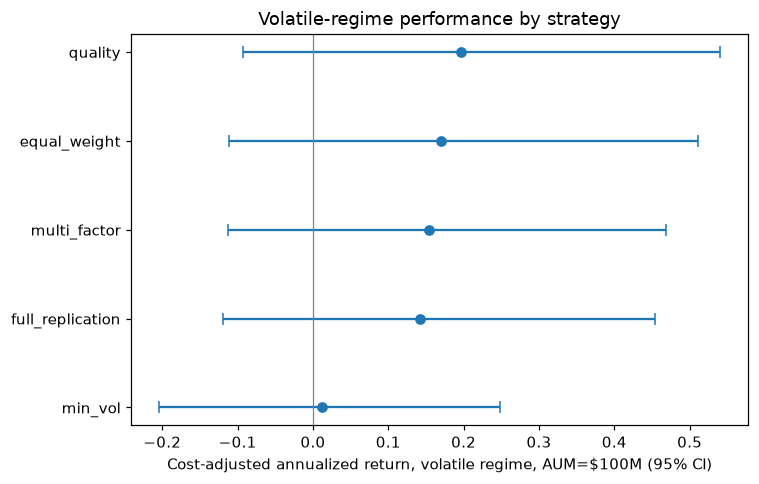

                  cost_adjusted_return  cost_adjusted_return_ci_low  cost_adjusted_return_ci_high
strategy                                                                                         
full_replication              0.141556                    -0.119304                      0.454495
equal_weight                  0.169449                    -0.111893                      0.511077
min_vol                       0.012142                    -0.203780                      0.248219
quality                       0.196985                    -0.092351                      0.540238
multi_factor                  0.153436                    -0.112585                      0.468339

min_vol's genuinely lower realized volatility does NOT translate into better volatile-regime
returns here -- the opposite of the textbook claim. See results/output/findings.txt.


In [6]:
full_results = pd.read_csv("../results/output/full_results.csv")

volatile = full_results[(full_results["regime"] == "volatile") & (full_results["aum"] == 1e8)]
volatile = volatile.set_index("strategy")[["cost_adjusted_return", "cost_adjusted_return_ci_low", "cost_adjusted_return_ci_high"]]

fig, ax = plt.subplots(figsize=(7, 4.5))
order = volatile["cost_adjusted_return"].sort_values().index
y = np.arange(len(order))
point = volatile.loc[order, "cost_adjusted_return"]
lo = point - volatile.loc[order, "cost_adjusted_return_ci_low"]
hi = volatile.loc[order, "cost_adjusted_return_ci_high"] - point
ax.errorbar(point, y, xerr=[lo, hi], fmt="o", capsize=4)
ax.set_yticks(y, order)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Cost-adjusted annualized return, volatile regime, AUM=$100M (95% CI)")
ax.set_title("Volatile-regime performance by strategy")
plt.tight_layout()
plt.show()

print(volatile)
print()
print("min_vol's genuinely lower realized volatility does NOT translate into better volatile-regime")
print("returns here -- the opposite of the textbook claim. See results/output/findings.txt.")

## 6. Capacity: does the edge survive at realistic size?

Real rebalancing costs (square-root-law market impact, reused from ExecEdge's model) applied
across $10M / $100M / $1B hypothetical AUM. A strategy's paper edge is only real if it survives
contact with its own trading costs at the size it would actually be run.

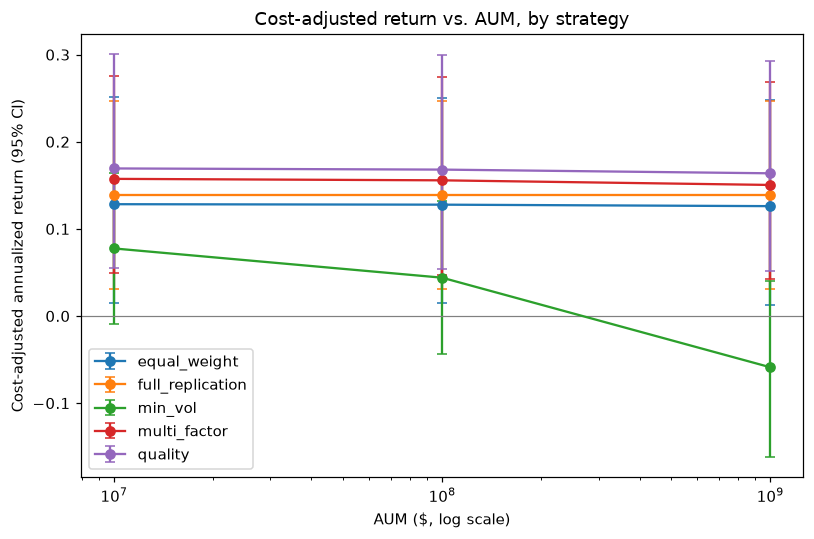

min_vol at   $10M AUM: cost-adjusted CAGR = +7.76%, 95% CI = [-0.94%, +16.39%]
min_vol at    $1B AUM: cost-adjusted CAGR = -5.88%, 95% CI = [-16.15%, +4.05%]
The point estimate drops sharply and the CI has widened to mostly-negative territory,
though it still touches slightly positive -- costs have not yet fully erased the
statistical case at this AUM, but the point estimate itself has turned negative.


In [7]:
all_regime = full_results[full_results["regime"] == "all"]

fig, ax = plt.subplots(figsize=(7.5, 5))
for strategy, group in all_regime.groupby("strategy"):
    group = group.sort_values("aum")
    point = group["cost_adjusted_return"]
    lo = point - group["cost_adjusted_return_ci_low"]
    hi = group["cost_adjusted_return_ci_high"] - point
    ax.errorbar(group["aum"], point, yerr=[lo, hi], marker="o", capsize=3, label=strategy)
ax.set_xscale("log")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("AUM ($, log scale)")
ax.set_ylabel("Cost-adjusted annualized return (95% CI)")
ax.set_title("Cost-adjusted return vs. AUM, by strategy")
ax.legend()
plt.tight_layout()
plt.show()

min_vol_10m = all_regime[(all_regime.strategy == "min_vol") & (all_regime.aum == 1e7)].iloc[0]
min_vol_1b = all_regime[(all_regime.strategy == "min_vol") & (all_regime.aum == 1e9)].iloc[0]
print(f"min_vol at   $10M AUM: cost-adjusted CAGR = {min_vol_10m.cost_adjusted_return:+.2%}, "
      f"95% CI = [{min_vol_10m.cost_adjusted_return_ci_low:+.2%}, {min_vol_10m.cost_adjusted_return_ci_high:+.2%}]")
print(f"min_vol at    $1B AUM: cost-adjusted CAGR = {min_vol_1b.cost_adjusted_return:+.2%}, "
      f"95% CI = [{min_vol_1b.cost_adjusted_return_ci_low:+.2%}, {min_vol_1b.cost_adjusted_return_ci_high:+.2%}]")
if min_vol_1b.cost_adjusted_return_ci_high < 0:
    print("The $1B CI is entirely negative -- not just diminished, statistically down.")
else:
    print("The point estimate drops sharply and the CI has widened to mostly-negative territory,")
    print("though it still touches slightly positive -- costs have not yet fully erased the")
    print("statistical case at this AUM, but the point estimate itself has turned negative.")

## 7. Honest findings

Programmatically derived from the comparison table above (`results/comparison.py::derive_honest_findings`),
not hand-written prose disconnected from the numbers.

In [8]:
with open("../results/output/findings.txt") as f:
    print(f.read())

- At $10,000,000 AUM, quality beat full replication after costs (+3.06% annualized difference).
- At $100,000,000 AUM, quality beat full replication after costs (+2.93% annualized difference).
- At $1,000,000,000 AUM, quality beat full replication after costs (+2.50% annualized difference).
- In volatile regimes at $10,000,000 AUM, min_vol underperformed full replication by -8.30% annualized; the low-vol claim is therefore regime-specific evidence, not a universal conclusion.
- In volatile regimes at $100,000,000 AUM, min_vol underperformed full replication by -12.94% annualized; the low-vol claim is therefore regime-specific evidence, not a universal conclusion.
- In volatile regimes at $1,000,000,000 AUM, min_vol underperformed full replication by -26.92% annualized; the low-vol claim is therefore regime-specific evidence, not a universal conclusion.
- At target 30 names, optimization had the lowest mean out-of-sample tracking error (3.23%); LASSO minus optimization TE was +9.01%.
- 

## 8. Limitations, disclosed

- **Pre-1976 survivorship bias**: point-in-time reconstruction relies on Wikipedia's changes
  log, which starts 1976-07-01. Dates before that fall back to today's constituent list.
- **Fundamentals are a current snapshot**: yfinance exposes no point-in-time historical
  fundamentals, so quality/value factors implicitly use look-ahead data at every historical
  rebalance. Disclosed explicitly in `data/fundamentals.py` and `smartbeta/quality.py`.
- **~86% price-history coverage**: 97 of 708 point-in-time constituents (2016-2026) have no
  reachable yfinance history -- real acquisitions/delistings (CELG, ATVI, TWTR, XLNX, SIVB,
  FRC, etc.), not silently dropped.
- **Free-float proxy**: `sharesOutstanding` is used as a proxy for the S&P's own official
  investable-weight-factor float, a disclosed approximation, not the real methodology.
- **Square-root-law impact model**: `Y=1.0` is execedge's own disclosed "textbook
  order-of-magnitude" convention, not a value fitted to this project's own data.
- **Cost timing**: rebalancing costs are applied as an instantaneous hit on the first trading
  day at/after each rebalance, not spread across real intraday execution (no intraday data).

See each module's own docstring for the full disclosure -- this notebook summarizes, it doesn't
replace them.